In [2]:
import torch
from torch import nn
from d2l import torch as d2l
import torchvision
from torch.utils import data
from torchvision import transforms
import random
import numpy as np
import os

f:\softwares\anaconda\envs\myenv\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: 
  warn(f"Failed to load image Python extension: {e}")


In [4]:
import openpyxl
import torch

# 打开现有的工作簿
path_metrics = './data/视频统计结果new.xlsx'

# 读取数据
workbook = openpyxl.load_workbook(path_metrics)
sheet = workbook.active

# 提取特征数据（B 和 C 列）
data_features = []
for row in sheet.iter_rows(min_row=2, max_row=229, min_col=2, max_col=3):
    for cell in row:
        data_features.append(cell.value)
features_matrix = [data_features[i:i+2] for i in range(0, len(data_features), 2)]
features = torch.tensor(features_matrix)

# 提取标签数据（D、F 和 H 列）
data_labels_d = [cell.value for row in sheet.iter_rows(min_row=2, max_row=229, min_col=4, max_col=4) for cell in row]
data_labels_f = [cell.value for row in sheet.iter_rows(min_row=2, max_row=229, min_col=6, max_col=6) for cell in row]
data_labels_h = [cell.value for row in sheet.iter_rows(min_row=2, max_row=229, min_col=8, max_col=8) for cell in row]

# 合并标签数据
data_labels = list(zip(data_labels_d, data_labels_f, data_labels_h))
labels = torch.tensor(data_labels)

# 输出特征和标签的形状
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

Features shape: torch.Size([228, 2])
Labels shape: torch.Size([228, 3])


In [5]:
#normalization
features_n = features.clone()
def normal(data):
    data1=data.clone()
    data1 = data1.reshape((-1,2))
    #print(data1.shape)
    data1[:,0] /= 50
    return data1

features_n = normal(features_n)

In [6]:
#dataLoader
def load_data(data_arrays, batch_size, is_train=True):
    dataset = data.TensorDataset(*data_arrays)  
    return data.DataLoader(dataset, batch_size, shuffle=is_train)  #每次从中随机挑选batch_size个样本

In [7]:
# 分割训练集和测试集
test_ratio = 0.05

leng = labels.shape[0] 
test_size = int(leng * test_ratio)

dataset = data.TensorDataset(features_n, labels)

train_dataset, test_dataset = data.random_split(dataset, [leng - test_size, test_size])

In [20]:
net = nn.Sequential(nn.Linear(2,64),
                    nn.ReLU(),
                    nn.Linear(64,32),
                    nn.ReLU(),
                    nn.Linear(32,3)
                    )

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=3, bias=True)
)

In [21]:
def train_epoch_ch3(net, train_iter, loss, updater):  
    if isinstance(net, torch.nn.Module):
        net.train()
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            updater.step()
        else:
            l.sum().backward()
            updater(X.shape[0])
    l = loss(net(features_n), labels)
    return float(l)

def evaluate(net, test_dataset, loss):
    """评估模型性能"""
    net.eval()
    test_iter = data.DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)
    with torch.no_grad():
        for X, y in test_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
    return float(l)

def train_ch3(net, train_iter, loss, num_epochs, lr, test_dataset):  
    L = []
    L_eval = []
    for epoch in range(num_epochs):
        if (epoch + 1) % 50 == 0:
            lr *= 0.5
        updater = torch.optim.SGD(net.parameters(), lr=lr)
        l = train_epoch_ch3(net, train_iter, loss, updater)  # 训练一个 epoch
        l_eval = evaluate(net, test_dataset, loss)  # 评估模型性能
        print(f'epoch {epoch + 1}, loss {l:f}, eval loss {l_eval:f}')
        L.append(l)
        L_eval.append(l_eval)
    return L, L_eval

loss = nn.MSELoss() 
batch_size, num_epochs, lr = 15, 500, 0.02
train_iter = data.DataLoader(train_dataset, batch_size, shuffle=True)
Loss, Loss_eval = train_ch3(net, train_iter, loss, num_epochs, lr, test_dataset)

epoch 1, loss 5.321136, eval loss 4.797194
epoch 2, loss 1.145684, eval loss 1.055615
epoch 3, loss 0.903203, eval loss 0.965053
epoch 4, loss 0.894394, eval loss 0.958169
epoch 5, loss 0.871359, eval loss 0.900695
epoch 6, loss 0.864367, eval loss 0.910597
epoch 7, loss 0.844503, eval loss 0.873364
epoch 8, loss 0.827809, eval loss 0.845613
epoch 9, loss 0.834314, eval loss 0.871026
epoch 10, loss 0.795497, eval loss 0.791140
epoch 11, loss 0.777930, eval loss 0.767803
epoch 12, loss 0.762321, eval loss 0.752125
epoch 13, loss 0.746042, eval loss 0.728957
epoch 14, loss 0.723890, eval loss 0.678688
epoch 15, loss 0.703341, eval loss 0.650054
epoch 16, loss 0.681594, eval loss 0.623342
epoch 17, loss 0.668894, eval loss 0.591216
epoch 18, loss 0.638590, eval loss 0.557677
epoch 19, loss 0.628515, eval loss 0.539807
epoch 20, loss 0.604358, eval loss 0.501298
epoch 21, loss 0.575164, eval loss 0.458927
epoch 22, loss 0.554116, eval loss 0.426251
epoch 23, loss 0.544548, eval loss 0.4025

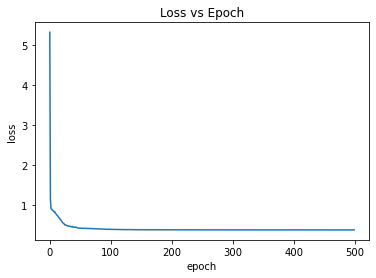

In [23]:
import matplotlib.pyplot as plt
plt.plot(Loss)
#plt.plot(Loss_eval,'blue')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss vs Epoch')
plt.savefig("./fig/loss1.png",dpi=1000)

In [24]:
import os
ckpt_path = './ckpt/'
torch.save(net,os.path.join(ckpt_path,'net1.pth'))